# Computational Statistical Mechanics - pamuduamarasinghe

# 1) 1D point-like gas particles interacting with a piston

Markov-chain algorithm

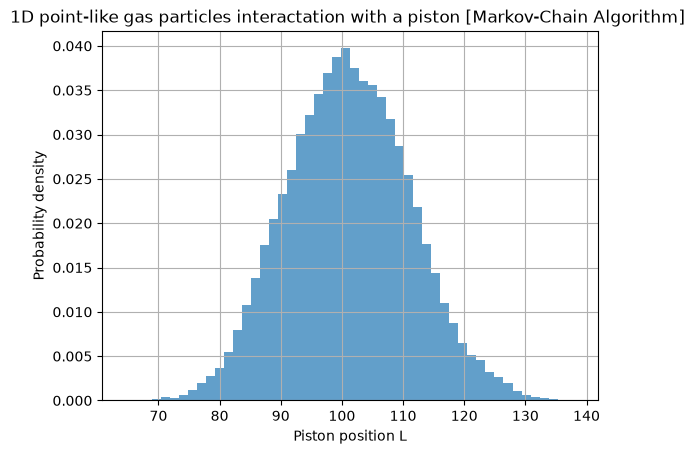

Mean L = 101.13958813352474
Variance = 100.5658895751591


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 100                  
B_P = 1               
delta = 1.0             
steps = 1000000

L = N

L_values = []

for step in range(steps):

    x = np.random.uniform(0, L, N)

    x_max = np.max(x)

    D_ = np.random.uniform(-delta, delta)

    Upsilon = np.exp(-B_P * D_)

    if (np.random.rand() < Upsilon) and (L + D_ > x_max):
        L = L + D_

    L_values.append(L)

L_values = np.array(L_values[1000:])

plt.hist(L_values, bins=50,density=True,alpha=0.7)
plt.xlabel("Piston position L")
plt.ylabel("Probability density")
plt.title("1D point-like gas particles interactation with a piston [Markov-Chain Algorithm] ")
plt.grid(True)
plt.show()

print("Mean L =", np.mean(L_values))
print("Variance =", np.var(L_values))

Direct sampling 

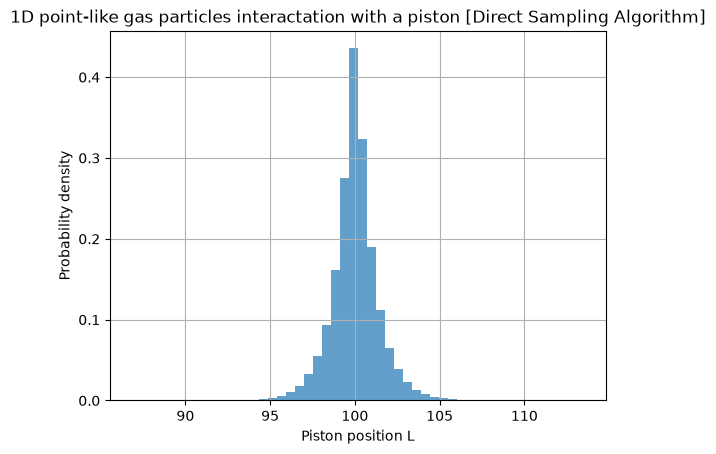

Mean L = 100.01279850630524
Variance = 1.9664966306190468


In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 100                  
B_P = 1                          
steps = 1000000


L_values = []

for i in range (steps):
    L = N
    x = np.random.uniform(0, L, N)
    x_max = np.max(x)
    D=-np.log(np.random.rand())/B_P

    L = x_max + D
    L_values.append(L)

L_values = np.array(L_values)

plt.hist(L_values, bins=50,density=True,alpha=0.7)
plt.xlabel("Piston position L")
plt.ylabel("Probability density")
plt.title("1D point-like gas particles interactation with a piston [Direct Sampling Algorithm]")
plt.grid(True)
plt.show()  

print("Mean L =", np.mean(L_values))
print("Variance =", np.var(L_values))

method comparison   MK chain and Direct Sampling

In [4]:
import numpy as np

def markov_chain(N, delta, iter):

    L = N + 1
    x = np.sort(np.random.uniform(0, L, N))

    total_L = 0

    for i in range(iter):

        particle = np.random.randint(0, N + 1)

        # Move a particle
        if particle < N:

            new_x = x[particle] + np.random.uniform(-delta, delta)

            left = x[particle-1] if particle > 0 else 0
            right = x[particle+1] if particle < N-1 else L

            if left < new_x < right:
                x[particle] = new_x

        # Move the piston
        else:

            new_L = L + np.random.uniform(-delta, delta)

            if new_L > x[-1]:
                P = np.exp(-(new_L - L))
                if np.random.rand() < P:
                    L = new_L

        total_L += L

    return total_L / iter


def direct_sampling(N, iter):

    total_L = 0

    for i in range(iter ):
        u = np.random.rand(N + 1)
        gaps = -np.log(u)
        L = np.sum(gaps)
        total_L += L
    return total_L / iter   



cases = [

    (4,0.1),
    (4,1.0),
    (6,0.1),
    (6,1.0)

]

iterations = [100,1000,10000,1000000,10000000]

print(" N   Delta    Iterations      Expected     Markov      Direct")
print("-"*75)

for N, delta in cases:

    expected = N + 1

    for M in iterations:
        markov = markov_chain(N, delta, M)
        direct = direct_sampling(N, M)
        print(f"{N:2d}   {delta:4.1f}   {M:10,d}   "
              f"{expected:8.3f}   {markov:8.3f}   {direct:8.3f}")

---------------------------------------------------------------------------
 N   Delta    Iterations      Expected     Markov      Direct
---------------------------------------------------------------------------
 4    0.1          100      5.000      5.082      4.979
 4    0.1        1,000      5.000      5.375      4.992
 4    0.1       10,000      5.000      4.802      4.992
 4    0.1    1,000,000      5.000      5.172      4.998
 4    0.1   10,000,000      5.000      5.506      4.999
 4    1.0          100      5.000      6.328      4.936
 4    1.0        1,000      5.000      4.078      5.020
 4    1.0       10,000      5.000      4.998      4.989
 4    1.0    1,000,000      5.000      4.974      5.002
 4    1.0   10,000,000      5.000      4.979      5.001
 6    0.1          100      7.000      6.938      7.262
 6    0.1        1,000      7.000      6.669      7.109
 6    0.1       10,000      7.000      7.478      6.976
 6    0.1    1,000,000      7.000      8.920      7.004
 6

 # 3) Deviations from the ideal gas law

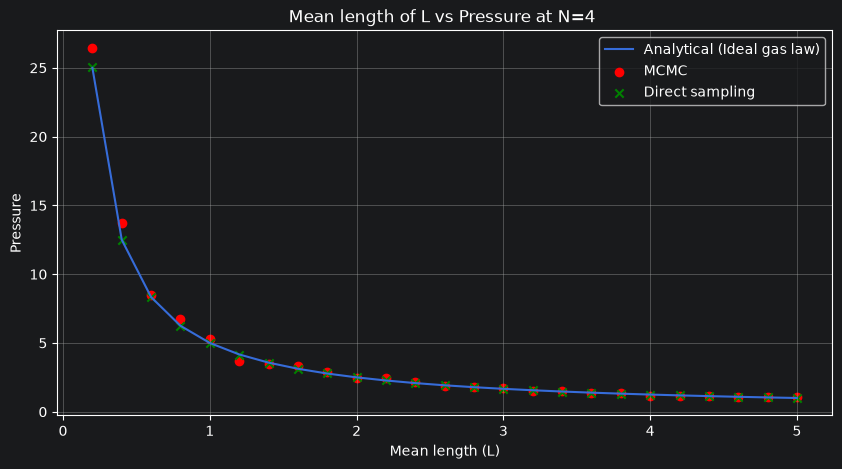

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def markov_chain(N, delta, iter,P,beta =1.0):
    beta_p =beta * P
    L = float(N + 1) /beta_p
    x = np.sort(np.random.uniform(0, L, N))

    total_L = 0

    for i in range(iter):

        particle = np.random.randint(0, N + 1)

        # Move a particle
        if particle < N:
            new_x = x[particle] + np.random.uniform(-delta, delta)
            left = x[particle-1] if particle > 0 else 0
            right = x[particle+1] if particle < N-1 else L

            if left < new_x < right:
                x[particle] = new_x

        # Move the piston
        else:

            new_L = L + np.random.uniform(-delta, delta)
            if new_L > x[-1]:
                prob = np.exp(-beta_p * (new_L - L))
                if np.random.rand() < prob:
                    L = new_L
        total_L += L

    return total_L / iter


def direct_sampling(N, iter,P,beta =1.0):
    beta_p =beta * P
    total_L = 0

    for i in range(iter ):
        u = np.random.rand(N + 1)
        gaps = -np.log(u)/beta_p
        L = np.sum(gaps)
        total_L += L
    return total_L / iter

N = 4
delta = 0.5
iterations = 100000
pressures = np.linspace(0.2, 5.0, 25)

mcmc_means = []
direct_means = []
analytical_means = []

for P in pressures:
    mcmc_means.append(markov_chain(N, delta, iterations,P))
    direct_means.append(direct_sampling(N, iterations,P))
    analytical_means.append((N+1)/P)

plt.figure(figsize=(10,5))
plt.plot(pressures,analytical_means,label="Analytical (Ideal gas law)")
plt.scatter(pressures,mcmc_means,color = 'red',marker ='o',label="MCMC")
plt.scatter(pressures,direct_means,color = 'green',marker='x',label="Direct sampling")

plt.title(f'Mean length of L vs Pressure at N=4 ')
plt.ylabel('Pressure')
plt.xlabel('Mean length (L)')
plt.legend()
plt.grid(True)
plt.show()
